# LOF Anomaly Detection

This notebook runs an end-to-end LOF pipeline on wind turbine gearbox data.
- Load and clean the data
- Engineer rolling-window features
- Train LOF on the early portion of the series
- Score anomalies and summarize results
- Visualize multiple features, scores, and anomaly rates

In [ ]:
from pathlib import Path; import sys
PROJECT_ROOT = Path.cwd().parents[0]; sys.path.insert(0, str(PROJECT_ROOT / "src"))
import matplotlib.pyplot as plt; import numpy as np; import pandas as pd; np.random.seed(42); plt.style.use("seaborn-v0_8")

In [ ]:
from data.lof_preprocessing import load_raw_data, select_feature_columns, dataset_overview, missing_rate_summary
from training.lof_training import train_lof, top_anomalies
from visualization.lof_plots import plot_feature_anomalies, plot_anomaly_score_timeline, plot_anomaly_score_histogram, plot_anomaly_rate_timeline, plot_anomaly_rate_by_split

,timestamp,gearbox_oil_temp,gearbox_bearing_temp,vibration_x,vibration_y,vibration_z,oil_pressure,particle_count
0,2025-01-01 00:00:00,59.24,65.85,0.0109,0.0092,0.0130,4.53,100
1,2025-01-01 00:10:00,60.12,66.83,0.0076,0.0065,0.0092,4.48,100
2,2025-01-01 00:20:00,59.50,65.16,0.0160,0.0136,0.0193,4.53,100
3,2025-01-01 00:30:00,60.28,65.80,0.0164,0.0140,0.0197,4.54,100
4,2025-01-01 00:40:00,60.72,66.84,0.0177,0.0151,0.0213,4.49,100


In [ ]:
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "turbine_5yr_complex_data.csv"; timestamp_col = "timestamp"
raw_df = load_raw_data(DATA_PATH, timestamp_col=timestamp_col)
raw_df.head()

,rows,features,start,end
0,262800,7,2025-01-01,2029-12-30 23:50:00


In [ ]:
feature_cols = select_feature_columns(raw_df, timestamp_col=timestamp_col)
overview_df = dataset_overview(raw_df, feature_cols, timestamp_col=timestamp_col)
overview_df

gearbox_oil_temp        0.0
gearbox_bearing_temp    0.0
vibration_x             0.0
vibration_y             0.0
vibration_z             0.0
oil_pressure            0.0
particle_count          0.0
dtype: float64

In [ ]:
missing_rate_summary(raw_df, feature_cols, top_n=10)

,total_rows,anomalies,anomaly_rate
0,262741,72645,0.276489


In [ ]:
results_df, summary_df, artifacts = train_lof(raw_df, timestamp_col=timestamp_col, feature_cols=feature_cols, rolling_window=60, n_neighbors=20, contamination=0.01, train_frac=0.7, val_frac=0.15)
summary_df

,timestamp,anomaly_score,is_anomaly
248080,2029-09-20 04:30:00,8.246304,1
248094,2029-09-20 06:50:00,8.216227,1
253559,2029-10-28 05:40:00,7.884395,1
251475,2029-10-13 18:20:00,7.883270,1
248072,2029-09-20 03:10:00,7.855814,1
253553,2029-10-28 04:40:00,7.822732,1
224743,2029-04-11 03:00:00,7.801264,1
248993,2029-09-26 12:40:00,7.773700,1
253560,2029-10-28 05:50:00,7.767658,1
253561,2029-10-28 06:00:00,7.721386,1


## Results and Visualizations

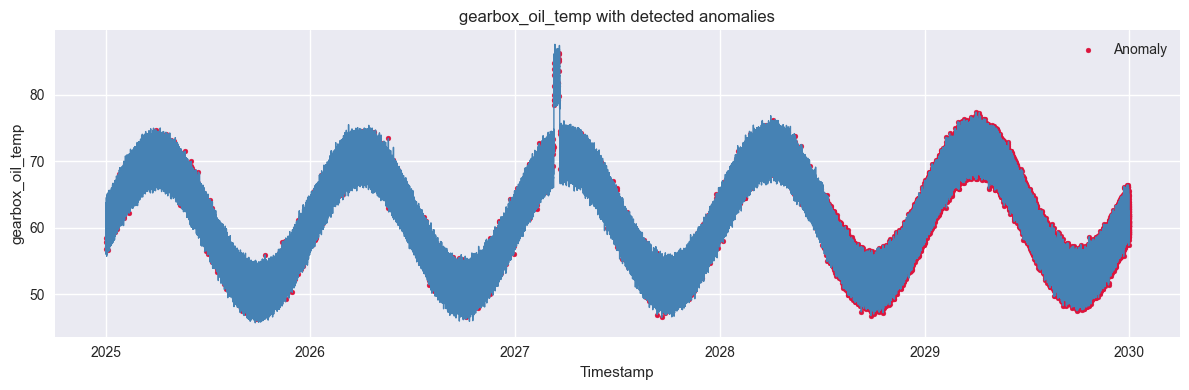

In [ ]:
top_anomalies(results_df, n=10, timestamp_col=timestamp_col)

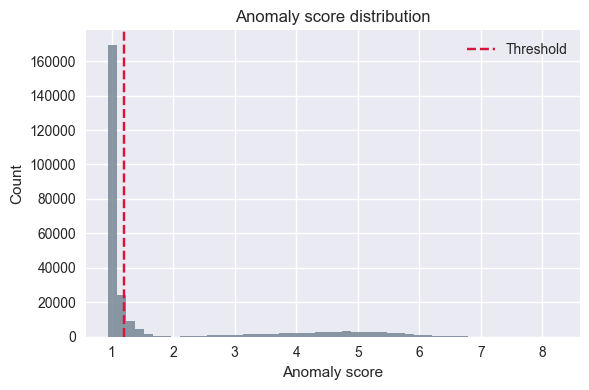

In [ ]:
plot_feature_anomalies(results_df, timestamp_col=timestamp_col, feature_cols=artifacts["base_features"], n_features=4, split_indices=(artifacts["train_end"], artifacts["val_end"]))

In [ ]:
plot_anomaly_score_timeline(results_df, timestamp_col=timestamp_col, threshold=artifacts["threshold"], split_indices=(artifacts["train_end"], artifacts["val_end"]))

In [ ]:
plot_anomaly_score_histogram(results_df, threshold=artifacts["threshold"])

In [ ]:
plot_anomaly_rate_timeline(results_df, timestamp_col=timestamp_col, window=144, split_indices=(artifacts["train_end"], artifacts["val_end"]))

In [ ]:
plot_anomaly_rate_by_split(results_df, artifacts["train_end"], artifacts["val_end"])